In [1]:
%pip install seaborn



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import sklearn

print(sklearn.__version__)



1.7.2


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.tree import DecisionTreeRegressor

In [5]:
df = pd.read_csv("house_prices.csv")

In [6]:
print("Shape:",df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:",df.duplicated().sum())

Shape: (21613, 21)

Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Duplicate rows: 0


In [7]:
print(df.dtypes)
print(df.describe())


id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront        object
view               int64
condition         object
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object
                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   14

In [8]:
print(df["waterfront"].value_counts())
print(df["condition"].value_counts())

waterfront
N    21450
Y      163
Name: count, dtype: int64
condition
Average      14031
Good          5679
Very Good     1701
Fair           172
Poor            30
Name: count, dtype: int64


In [9]:
print("Minimum price:",df["price"].min())
print("Maximum price:", df["price"].max())
print("Average price:", df["price"].mean())
print("Median price:", df["price"].median())

Minimum price: 75000.0
Maximum price: 7700000.0
Average price: 540088.1417665294
Median price: 450000.0


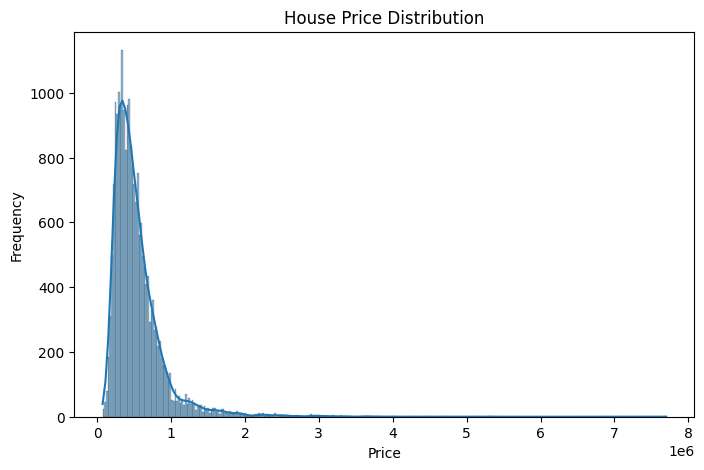

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"],kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

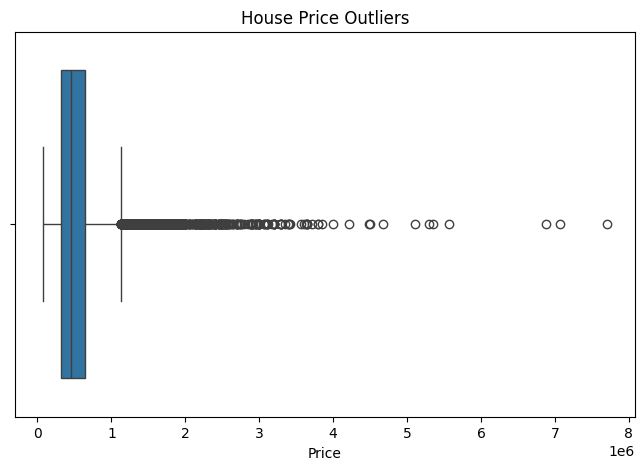

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("House Price Outliers")
plt.xlabel("Price")
plt.show()

In [12]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print("Potential outliers:", len(outliers))

Q1: 321950.0
Q3: 645000.0
IQR: 323050.0
Lower bound: -162625.0
Upper bound: 1129575.0
Potential outliers: 1146


In [13]:
correlation = df.corr(numeric_only=True)["price"].sort_values(ascending=False)

print(correlation)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


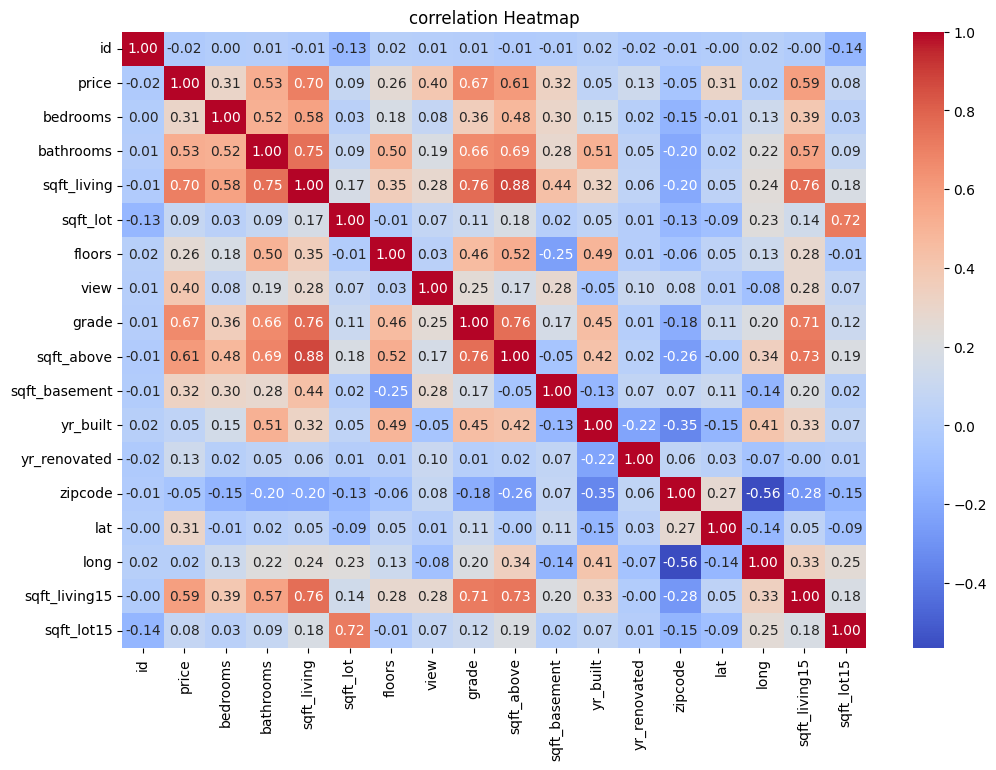

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("correlation Heatmap")
plt.show()

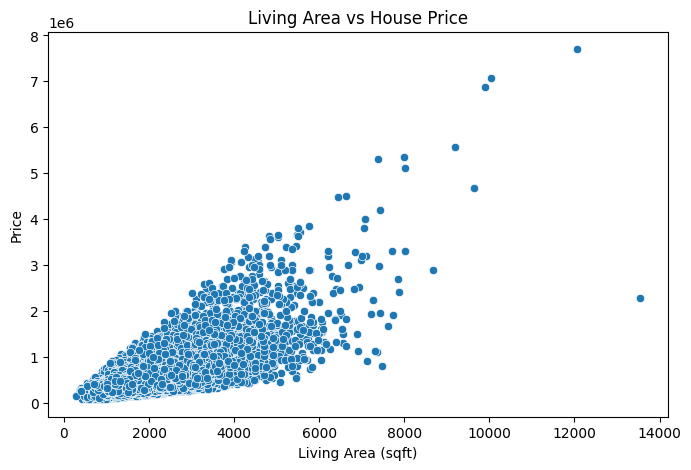

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="sqft_living", y="price")

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.show()

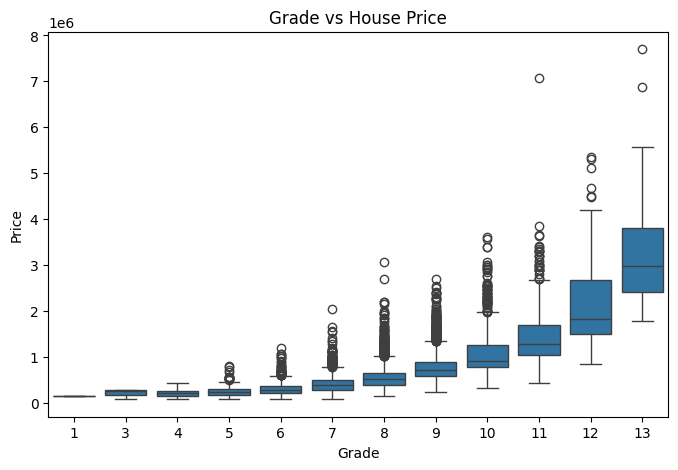

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="grade", y="price")

plt.title("Grade vs House Price")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

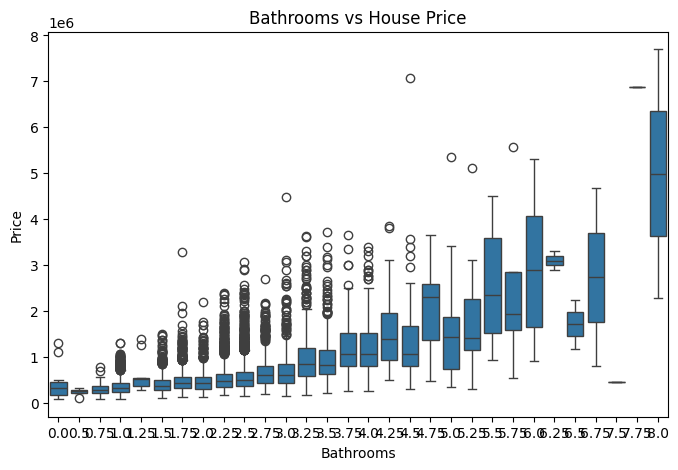

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="bathrooms", y="price")

plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")

plt.show()

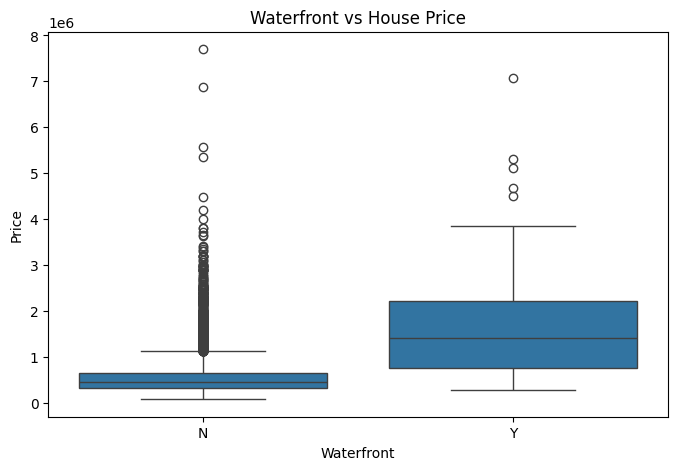

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="waterfront", y="price")

plt.title("Waterfront vs House Price")
plt.xlabel("Waterfront")
plt.ylabel("Price")

plt.show()

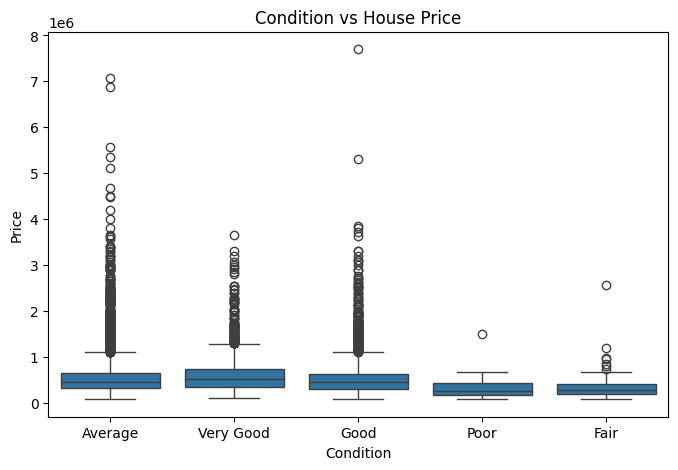

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="condition", y="price")

plt.title("Condition vs House Price")
plt.xlabel("Condition")
plt.ylabel("Price")

plt.show()

In [20]:
df = df.drop("id", axis=1)

df["date"] = pd.to_datetime(df["date"])

df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

df = df.drop("date", axis=1)
print(df[["sale_year", "sale_month"]].head())

   sale_year  sale_month
0       2014          10
1       2014          12
2       2015           2
3       2014          12
4       2015           2


In [21]:
df["waterfront"] = df["waterfront"].map({"N":0,"Y":1})
print(df["waterfront"].value_counts())

condition_map = {"Poor":1,"Fair":2,"Average":3,"Good":4,"Very Good":5}
df["condition"] = df["condition"].map(condition_map)

print(df.head())
print(df.dtypes)

waterfront
0    21450
1      163
Name: count, dtype: int64
      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  221900.0         3       1.00         1180      5650     1.0           0   
1  538000.0         3       2.25         2570      7242     2.0           0   
2  180000.0         2       1.00          770     10000     1.0           0   
3  604000.0         4       3.00         1960      5000     1.0           0   
4  510000.0         3       2.00         1680      8080     1.0           0   

   view  condition  grade  ...  sqft_basement  yr_built  yr_renovated  \
0     0          3      7  ...              0      1955             0   
1     0          3      7  ...            400      1951          1991   
2     0          3      6  ...              0      1933             0   
3     0          5      7  ...            910      1965             0   
4     0          3      8  ...              0      1987             0   

   zipcode      lat     lon

In [22]:
df = df.drop("zipcode", axis=1)

print(df.shape)
print(df.dtypes)

(21613, 20)
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
sale_year          int32
sale_month         int32
dtype: object


In [23]:
X = df.drop("price",axis=1)
Y = df["price"]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (21613, 19)
Y shape: (21613,)


In [24]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

print("Training Data:",X_train.shape)
print("Testing Data:",X_test.shape)

Training Data: (17290, 19)
Testing Data: (4323, 19)


In [25]:
model = LinearRegression()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)
print("Model Training completed.")

Model Training completed.


In [26]:
mae = mean_absolute_error(Y_test,Y_pred)
mse = mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test,Y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 127642.48014397253
MSE: 45778142396.492004
RMSE: 213958.2725591418
R² Score: 0.6971878689972255


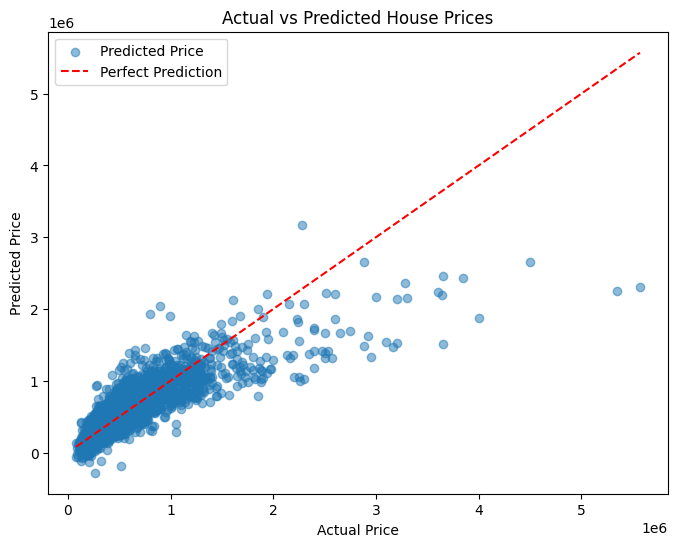

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    Y_test,
    Y_pred,
    alpha=0.5,
    label="Predicted Price"
)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()

plt.show()

In [28]:
tree_model = DecisionTreeRegressor(random_state=42,max_depth=10)
tree_model.fit(X_train,Y_train)
tree_pred = tree_model.predict(X_test)
print("Decision tree training completed")

Decision tree training completed


In [29]:
tree_mae = mean_absolute_error(Y_test, tree_pred)
tree_mse = mean_squared_error(Y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(Y_test, tree_pred)

print("Decision Tree Results")
print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R² Score:", tree_r2)

Decision Tree Results
MAE: 96372.4657772253
MSE: 37296736656.79994
RMSE: 193123.63049818616
R² Score: 0.7532904631936235


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,max_depth=15,random_state=42,n_jobs=-1)
rf_model.fit(X_train, Y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [31]:
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(Y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 74111.89145935819
MSE: 22985867984.87508
RMSE: 151610.90984779122
R² Score: 0.8479536454938842


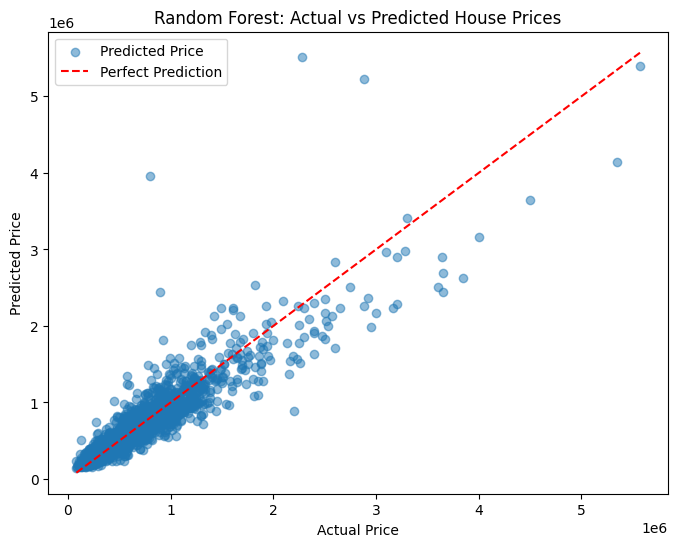

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    Y_test,
    rf_pred,
    alpha=0.5,
    label="Predicted Price"
)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted House Prices")
plt.legend()

plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
8           grade    0.318769
2     sqft_living    0.276018
13            lat    0.156717
14           long    0.066150
5      waterfront    0.032269
11       yr_built    0.032017
15  sqft_living15    0.031798
9      sqft_above    0.019028
3        sqft_lot    0.012814
16     sqft_lot15    0.012398
1       bathrooms    0.010686
6            view    0.010201
10  sqft_basement    0.005521
18     sale_month    0.004736
7       condition    0.002776
0        bedrooms    0.002755
12   yr_renovated    0.002283
4          floors    0.001881
17      sale_year    0.001182


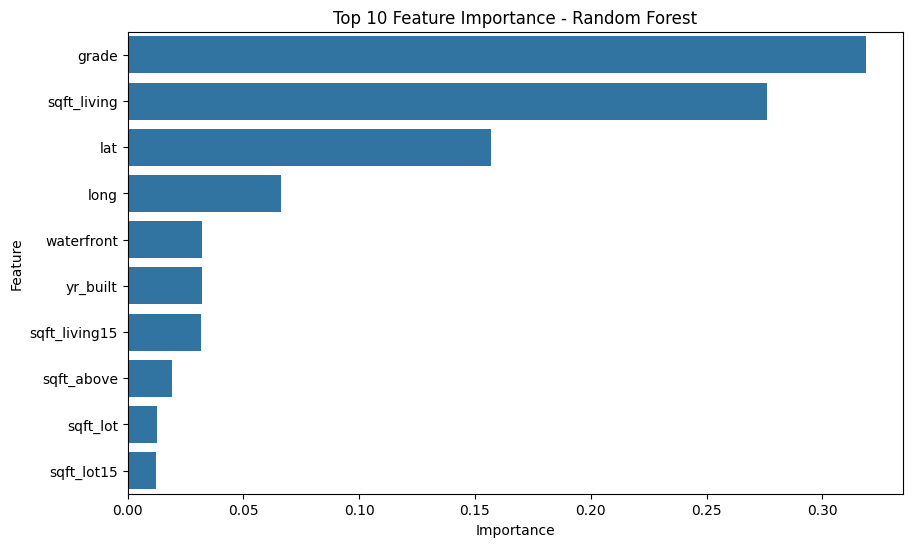

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [35]:
#Classification

# Create price categories
df["price_category"] = pd.qcut(df["price"],q=3,labels=["Low","Medium","High"])

print(df["price_category"].value_counts())

price_category
Low       7226
Medium    7223
High      7164
Name: count, dtype: int64


In [36]:
X_classification = df.drop(["price","price_category"],axis=1)
Y_classification = df["price_category"]

print("Features shape:", X_classification.shape)
print("Target shape:", Y_classification.shape)

Features shape: (21613, 19)
Target shape: (21613,)


In [37]:
X_class_train, X_class_test, Y_class_train, Y_class_test = train_test_split(
    X_classification,
    Y_classification,
    test_size=0.2,
    random_state=42,
    stratify=Y_classification
)

print("Classification training data:", X_class_train.shape)
print("Classification testing data:", X_class_test.shape)

Classification training data: (17290, 19)
Classification testing data: (4323, 19)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [39]:
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_class_train, Y_class_train)

log_pred = log_pipeline.predict(X_class_test)

print("Scaled Logistic Regression training completed.")

Scaled Logistic Regression training completed.


In [40]:
accuracy = accuracy_score(Y_class_test,log_pred)
precision = precision_score(Y_class_test,log_pred,average="weighted")
recall = recall_score(Y_class_test,log_pred,average="weighted")
f1 = f1_score(Y_class_test,log_pred,average="weighted")

print("Logistic Regression Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(Y_class_test, log_pred))

Logistic Regression Results
Accuracy: 0.7344436733749711
Precision: 0.7388891062228583
Recall: 0.7344436733749711
F1 Score: 0.7362067027434912

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.75      0.77      1433
         Low       0.81      0.81      0.81      1445
      Medium       0.60      0.64      0.62      1445

    accuracy                           0.73      4323
   macro avg       0.74      0.73      0.74      4323
weighted avg       0.74      0.73      0.74      4323



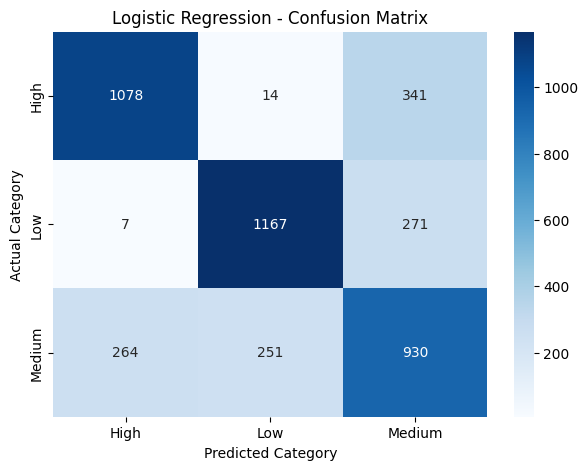

In [41]:
cm = confusion_matrix(Y_class_test,log_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["High","Low","Medium"],yticklabels=["High","Low","Medium"])

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [42]:
from sklearn.tree import DecisionTreeClassifier

tree_classifier = DecisionTreeClassifier(random_state=42,max_depth=10)
tree_classifier.fit(X_class_train,Y_class_train)
tree_class_pred = tree_classifier.predict(X_class_test)

print("Decision Tree Classifier  training completed.")

Decision Tree Classifier  training completed.


In [43]:
accuracy = accuracy_score(Y_class_test,tree_class_pred)
precision = precision_score(Y_class_test,tree_class_pred,average="weighted")
recall = recall_score(Y_class_test,tree_class_pred,average="weighted")
f1 = f1_score(Y_class_test,tree_class_pred,average="weighted")

print("Decision Tree Classifier Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(Y_class_test, tree_class_pred))

Decision Tree Classifier Results
Accuracy: 0.8003701133472125
Precision: 0.8030852709300781
Recall: 0.8003701133472125
F1 Score: 0.8014771485687049

Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.83      0.83      1433
         Low       0.88      0.84      0.86      1445
      Medium       0.70      0.73      0.72      1445

    accuracy                           0.80      4323
   macro avg       0.80      0.80      0.80      4323
weighted avg       0.80      0.80      0.80      4323



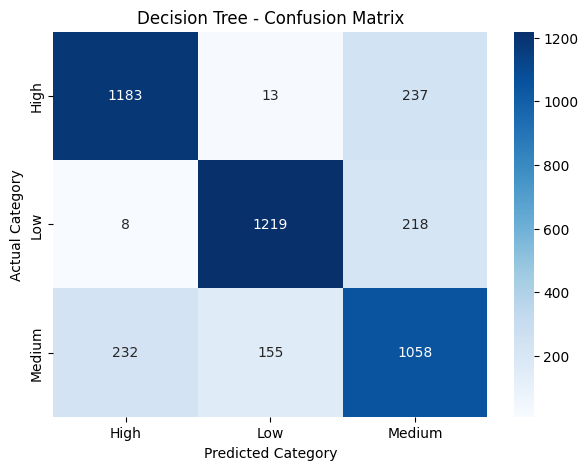

In [44]:
cm_tree = confusion_matrix(Y_class_test,tree_class_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm_tree,annot=True,fmt="d",cmap="Blues",xticklabels=["High","Low","Medium"],yticklabels=["High","Low","Medium"])

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Decision Tree - Confusion Matrix")
plt.show()


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100,max_depth=15,random_state=42,n_jobs=-1)
rf_classifier.fit(X_class_train,Y_class_train)
rf_class_pred = rf_classifier.predict(X_class_test)

print("Random Forest Classifier training completed")

Random Forest Classifier training completed


In [46]:
accuracy = accuracy_score(Y_class_test, rf_class_pred)
precision = precision_score(
    Y_class_test,
    rf_class_pred,
    average="weighted"
)
recall = recall_score(
    Y_class_test,
    rf_class_pred,
    average="weighted"
)
f1 = f1_score(
    Y_class_test,
    rf_class_pred,
    average="weighted"
)

print("Random Forest Classifier Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(Y_class_test, rf_class_pred))

Random Forest Classifier Results
Accuracy: 0.8380754105944945
Precision: 0.8408083311858605
Recall: 0.8380754105944945
F1 Score: 0.839067168312131

Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.84      0.86      1433
         Low       0.89      0.88      0.89      1445
      Medium       0.75      0.79      0.77      1445

    accuracy                           0.84      4323
   macro avg       0.84      0.84      0.84      4323
weighted avg       0.84      0.84      0.84      4323



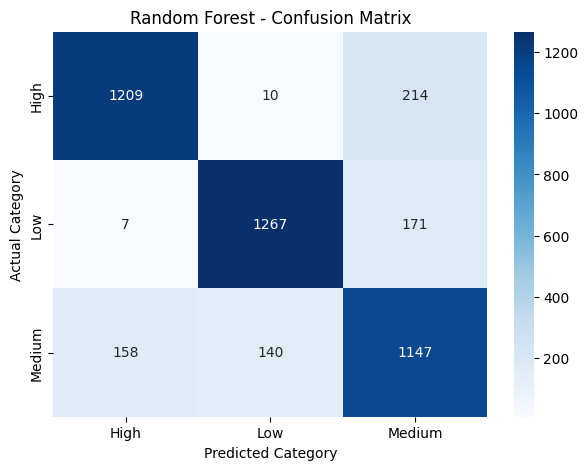

In [47]:
cm_rf = confusion_matrix(Y_class_test, rf_class_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [48]:
classification_results =pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[accuracy_score(Y_class_test, log_pred),accuracy_score(Y_class_test, tree_class_pred),accuracy_score(Y_class_test, rf_class_pred)],
    "Precision":[precision_score(Y_class_test, log_pred, average="weighted"),precision_score(Y_class_test, tree_class_pred, average="weighted"),precision_score(Y_class_test, rf_class_pred, average="weighted")],
    "Recall":[recall_score(Y_class_test, log_pred, average="weighted"),recall_score(Y_class_test, tree_class_pred, average="weighted"),recall_score(Y_class_test, rf_class_pred, average="weighted")],
    "F1 Score":[f1_score(Y_class_test, log_pred, average="weighted"),f1_score(Y_class_test, tree_class_pred, average="weighted"),f1_score(Y_class_test, rf_class_pred, average="weighted")]
    })
print(classification_results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.734444   0.738889  0.734444  0.736207
1        Decision Tree  0.800370   0.803085  0.800370  0.801477
2        Random Forest  0.838075   0.840808  0.838075  0.839067


In [49]:
classification_importance = pd.DataFrame({"Feature":X_class_train.columns,"Importance":rf_classifier.feature_importances_})
classification_importance = classification_importance.sort_values(by="Importance",ascending=False)

print(classification_importance)

          Feature  Importance
13            lat    0.290152
2     sqft_living    0.125327
8           grade    0.090718
15  sqft_living15    0.082984
9      sqft_above    0.069378
14           long    0.063443
16     sqft_lot15    0.050343
11       yr_built    0.048629
3        sqft_lot    0.047235
1       bathrooms    0.029894
10  sqft_basement    0.022320
18     sale_month    0.020253
0        bedrooms    0.017094
6            view    0.011910
7       condition    0.011480
4          floors    0.008913
17      sale_year    0.005104
12   yr_renovated    0.003688
5      waterfront    0.001137


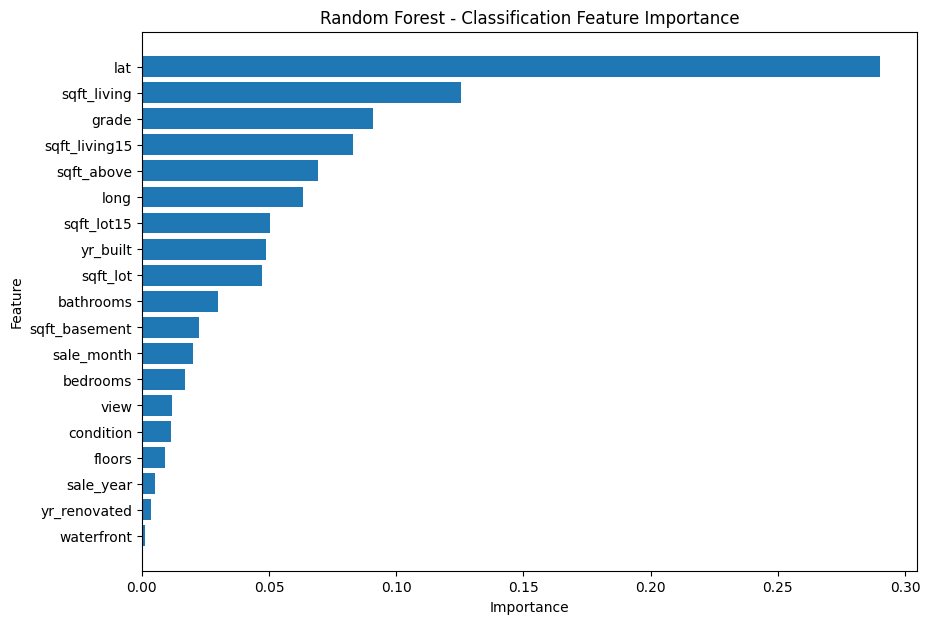

In [50]:
plt.figure(figsize=(10, 7))

plt.barh(
    classification_importance["Feature"],
    classification_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Classification Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [51]:
print(X.columns.tolist())

['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month']


In [54]:
def predict_house(
    bedrooms,
    bathrooms,
    sqft_living,
    sqft_lot,
    floors,
    waterfront,
    view,
    condition,
    grade,
    sqft_above,
    sqft_basement,
    yr_built,
    yr_renovated,
    lat,
    long,
    sqft_living15,
    sqft_lot15,
    sale_year,
    sale_month
):
    
    # Input validation
    
    values = {
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "sqft_living": sqft_living,
        "sqft_lot": sqft_lot,
        "floors": floors,
        "waterfront": waterfront,
        "view": view,
        "condition": condition,
        "grade": grade,
        "sqft_above": sqft_above,
        "sqft_basement": sqft_basement,
        "yr_built": yr_built,
        "yr_renovated": yr_renovated,
        "lat": lat,
        "long": long,
        "sqft_living15": sqft_living15,
        "sqft_lot15": sqft_lot15,
        "sale_year": sale_year,
        "sale_month": sale_month
    }

    # Check for missing values
    for name, value in values.items():
        if value is None:
            raise ValueError(f"{name} cannot be empty.")

    # Check numeric values
    for name, value in values.items():
        if not isinstance(value, (int, float)):
            raise ValueError(f"{name} must be a number.")

    # Non-negative checks
    non_negative = [
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "sqft_lot",
        "floors",
        "view",
        "sqft_above",
        "sqft_basement",
        "sqft_living15",
        "sqft_lot15"
    ]

    for name in non_negative:
        if values[name] < 0:
            raise ValueError(f"{name} cannot be negative.")

    # Specific range checks
    if waterfront not in [0, 1]:
        raise ValueError("waterfront must be 0 or 1.")

    if view not in range(5):
        raise ValueError("view must be between 0 and 4.")

    if condition not in range(1, 6):
        raise ValueError("condition must be between 1 and 5.")

    if grade < 1 or grade > 13:
        raise ValueError("grade must be between 1 and 13.")

    if sale_month < 1 or sale_month > 12:
        raise ValueError("sale_month must be between 1 and 12.")

    if yr_built < 1800 or yr_built > sale_year:
        raise ValueError("Invalid yr_built.")

    if yr_renovated != 0 and (yr_renovated < 1800 or yr_renovated > sale_year):
        raise ValueError("Invalid yr_renovated.")

    # Create input DataFrame

    input_data = pd.DataFrame([[
        bedrooms,
        bathrooms,
        sqft_living,
        sqft_lot,
        floors,
        waterfront,
        view,
        condition,
        grade,
        sqft_above,
        sqft_basement,
        yr_built,
        yr_renovated,
        lat,
        long,
        sqft_living15,
        sqft_lot15,
        sale_year,
        sale_month
    ]], columns=X.columns)

    # Predictions

    predicted_price = rf_model.predict(input_data)[0]

    predicted_category = rf_classifier.predict(input_data)[0]

    # Output

    print("Predicted House Price: ${:,.2f}".format(predicted_price))
    print("Predicted Price Category:", predicted_category)

In [57]:
predict_house(
    bedrooms=3,
    bathrooms=2,
    sqft_living=2000,
    sqft_lot=5000,
    floors=1,
    waterfront=0,
    view=0,
    condition=3,
    grade=7,
    sqft_above=1800,
    sqft_basement=200,
    yr_built=1990,
    yr_renovated=0,
    lat=47.5,
    long=-122.2,
    sqft_living15=1900,
    sqft_lot15=5000,
    sale_year=2014,
    sale_month=6
)

Predicted House Price: $337,062.76
Predicted Price Category: Low


In [58]:
import joblib

joblib.dump(rf_model, "house_price_regression_model.pkl")
joblib.dump(rf_classifier, "house_price_classification_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [59]:
import os

print(os.path.exists("house_price_regression_model.pkl"))
print(os.path.exists("house_price_classification_model.pkl"))

True
True


In [60]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree","Random Forest"],
    "MAE": [127642.48,96372.47,74111.89],
    "RMSE": [213958.27,193123.63,151610.91],
    "R2 Score": [0.6972,0.7533,0.8480]
})

print(regression_results)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  127642.48  213958.27    0.6972
1      Decision Tree   96372.47  193123.63    0.7533
2      Random Forest   74111.89  151610.91    0.8480


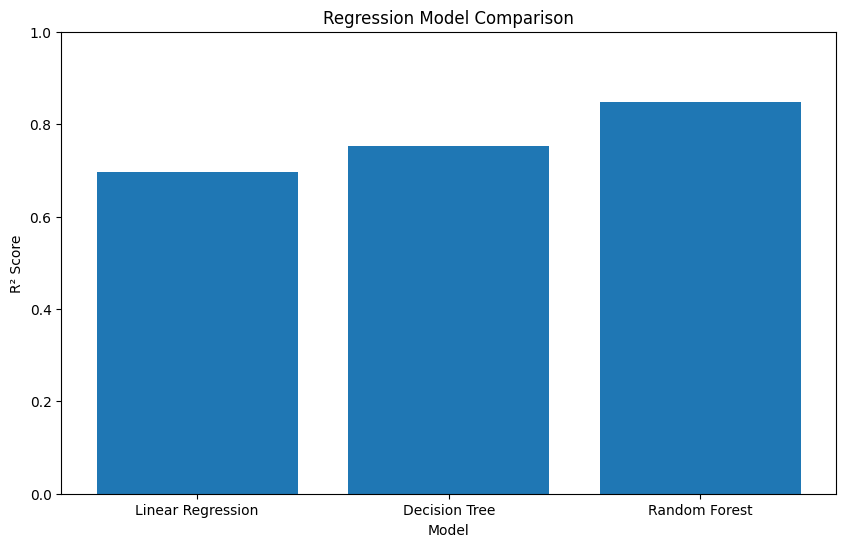

In [61]:
plt.figure(figsize=(10, 6))

plt.bar(
    regression_results["Model"],
    regression_results["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison")
plt.ylim(0, 1)

plt.show()

In [62]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy": [0.7344,0.8004,0.8381],
    "Precision": [0.7389,0.8031,0.8408],
    "Recall": [0.7344,0.8004,0.8381],
    "F1 Score": [0.7362,0.8015,0.8391]
})

print(classification_results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7344     0.7389  0.7344    0.7362
1        Decision Tree    0.8004     0.8031  0.8004    0.8015
2        Random Forest    0.8381     0.8408  0.8381    0.8391


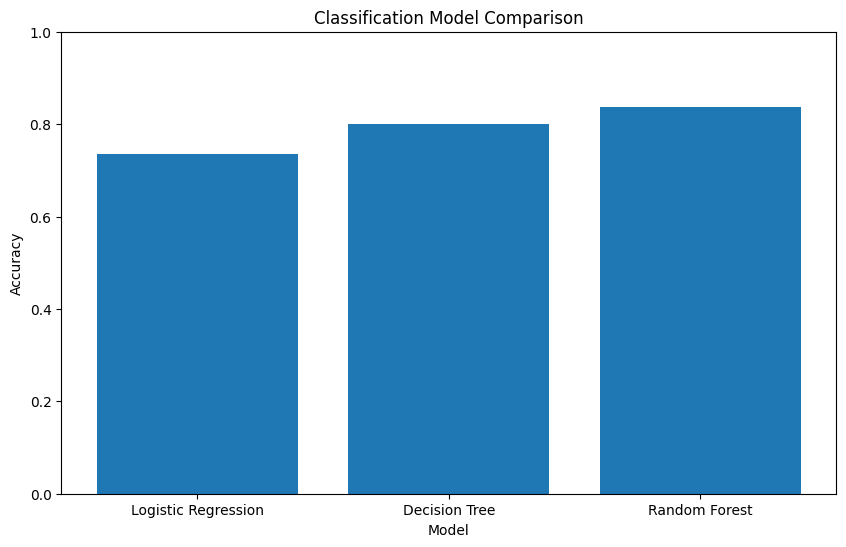

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Classification Model Comparison")
plt.ylim(0, 1)

plt.show()